In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [3]:
def safe_select(grouped, cols):
    """Safely select columns from a grouped DataFrame."""
    return grouped[cols] if len(cols) > 0 else pd.DataFrame(index=grouped.index)


In [4]:
def unwrap_scalar(v):
    if isinstance(v, (list, tuple)) and len(v) == 1:
        return v[0]
    return v


In [5]:
def plot_reward(path):

    df = pd.read_csv(path)

    df = df.dropna(
        subset=["episode_reward_mean", "episode_reward_max", "episode_reward_min"]
    )

    iters = df["training_iteration"]

    plt.figure(figsize=(10, 6)) 
    plt.plot(iters, df["episode_reward_mean"], label="Mean Reward")
    plt.fill_between(
        iters,
        df["episode_reward_min"],
        df["episode_reward_max"],
        alpha=0.2,
        label="Min–Max Range"
    )
    plt.xlabel("Training Iteration")
    plt.ylabel("Episode Reward")
    plt.title("Training Rewards Over Time")
    plt.legend()
    plt.grid(True)
    plt.show()


In [6]:
def plot_constrains(csv_path, ax_g, metric_cols, references, reducer="mean"):
    import pandas as pd

    df = pd.read_csv(csv_path)

    # 1) Validate step
    if "step" not in df.columns:
        ax_g.set_title("No step column found")
        ax_g.axis("off")
        return

    # 2) Validate metrics
    missing = [m for m in metric_cols if m not in df.columns]
    if missing:
        raise ValueError(f"Columns not found in CSV: {missing}")
    if not metric_cols:
        ax_g.set_title("No metrics provided")
        ax_g.axis("off")
        return

    # 3) Group by step (choose reducer)
    valid_reducers = {"mean", "sum", "median", "min", "max"}
    if reducer not in valid_reducers:
        raise ValueError(f"Invalid reducer='{reducer}'. Use one of {sorted(valid_reducers)}")

    grouped = (
        df.groupby("step")[metric_cols]
          .agg(reducer)
          .reset_index()
          .sort_values("step")
    )

    # 4) Plot aggregated series
    for m in metric_cols:
        if m == "total_import" or m == "total_export":
            ax_g.plot(grouped["step"], grouped[m], linestyle="--", linewidth=2.0, label=f"{m} ({reducer})")
        else:
            ax_g.plot(grouped["step"], grouped[m], linewidth=2.0, label=f"{m} ({reducer})")


    if references is not None:
        ax_g.axhline(
            y=references[0],
            linestyle=":",
            linewidth=3,
            color="black",
            label="Reference Power"
        )

    ax_g.set_title("Metrics grouped by step")
    ax_g.set_xlabel("step")
    ax_g.set_ylabel("Value")
    ax_g.legend()
    ax_g.grid(alpha=0.3)

In [7]:
def plot_lagrange_multipliers(csv_path, ax, lm_columns=None):
    """
    Plot one or multiple Lagrange multipliers (lm1, lm2, ...)
    aggregated per episode.

    Parameters
    ----------
    csv_path : str
    ax : matplotlib axis
    lm_columns : list[str] or None
        If None, automatically selects all columns starting with 'lm'.
    """

    import pandas as pd

    df = pd.read_csv(csv_path)

    if "step" not in df.columns:
        ax.set_title("No episode column found")
        ax.axis("off")
        return

    # --- Auto-detect lm columns if not provided ---
    if lm_columns is None:
        lm_columns = [c for c in df.columns if c.startswith("mu")]

    if not lm_columns:
        ax.set_title("No Lagrange multipliers found")
        ax.axis("off")
        return

    # --- Aggregate per episode ---
    agg_dict = {}
    for lm in lm_columns:
        agg_dict[f"{lm}_mean"] = (lm, "mean")
        agg_dict[f"{lm}_min"] = (lm, "min")
        agg_dict[f"{lm}_max"] = (lm, "max")

    stats = (
        df.groupby("step")
          .agg(**agg_dict)
          .reset_index()
    )

    # --- Plot each multiplier ---
    for lm in lm_columns:
        ax.plot(
            stats["step"],
            stats[f"{lm}_mean"],
            linewidth=2,
            label=f"{lm} mean"
        )

        ax.fill_between(
            stats["step"],
            stats[f"{lm}_min"],
            stats[f"{lm}_max"],
            alpha=0.2,
            label=f"{lm} range"
        )

    ax.set_title("Market price per step")
    ax.set_xlabel("step")
    ax.set_ylabel("Value")
    ax.set_ylim([10,100])
    ax.legend()
    ax.grid(alpha=0.3)


In [8]:
def full_analysis_plot(training_path, eval_path, mu_path,seller_power_reference=None):

    linewidth = 2.5
    figsize = (16, 12)

    # --- Load data ---
    df_train = pd.read_csv(training_path)
    df_eval  = pd.read_csv(eval_path)

    df_train = df_train.dropna(
       subset=["env_runners/episode_return_mean", "env_runners/episode_return_max", "env_runners/episode_return_min"]
    )

    # --- Column detection ---
    A0_cols = [
        c for c in df_eval.columns
        # if c.startswith("seller_") and c.endswith("_total_power")
        if c.startswith("A0_") and c.endswith("_state_2")
    ]

    A1_cols = [
        c for c in df_eval.columns
        if c.startswith("A1_") and c.endswith("_state_2")
    ]

    A0_reward_cols = [
        c for c in df_eval.columns
        if c.startswith("A0_") and c.endswith("_reward")
    ]

    A1_reward_cols = [
        c for c in df_eval.columns
        if c.startswith("A1_") and c.endswith("_reward")
    ]

    grouped = df_eval.groupby('step').mean(numeric_only=True)
    grouped.columns.tolist()

    seller_means = grouped[A0_cols]
    buyer_means  = grouped[A1_cols]
    A0_reward_means = grouped[A0_reward_cols]
    A1_reward_means = grouped[A1_reward_cols]



    fig, ax = plt.subplots(3, 2, figsize=figsize)
    ax = ax.flatten()

    # === 1️⃣ Training rewards ===
    iters = df_train["training_iteration"]
    ax[0].plot(iters, df_train["env_runners/episode_return_mean"], linewidth=linewidth)
    ax[0].fill_between(
        iters,
        df_train["env_runners/episode_return_min"],
        df_train["env_runners/episode_return_max"],
        alpha=0.2
    )
    ax[0].set_title("Training Rewards Over Time")
    ax[0].grid(alpha=0.3)

    # === 2️⃣ Agent rewards ===
    for col in A0_reward_means.columns:
        ax[1].plot(A0_reward_means.index, A0_reward_means[col], label=col)
    for col in A1_reward_means.columns:
        ax[1].plot(A1_reward_means.index, A1_reward_means[col], label=col, linestyle="--")
    ax[1].set_title("Mean Agent Reward per Step")
    ax[1].legend()
    ax[1].grid(alpha=0.3)

    # === 3️⃣ Seller power ===
    for col in seller_means.columns:
        ax[2].plot(seller_means.index, seller_means[col], label=col)



    if seller_power_reference is not None:
        ax[2].axhline(
            y=seller_power_reference[0],
            linestyle=":",
            linewidth=2,
            color="red",
            # label="Max power G1"
        )
        ax[2].axhline(
            y=seller_power_reference[1],
            linestyle=":",
            linewidth=2,
            color="red",
            # label="Max power G2"
        )
        ax[2].axhline(
            y=seller_power_reference[2],
            linestyle=":",
            linewidth=2,
            color="red",
            # label="Max power G3"
        )
        ax[2].axhline(
            y=seller_power_reference[3],
            linestyle=":",
            linewidth=2,
            color="red",
            # label="Max power G4"
        )

    ax[2].set_title("Mean Sold Power per Step")
    ax[2].legend()
    ax[2].grid(alpha=0.3)

    # === 4️⃣ Buyer prices ===
    for col in buyer_means.columns:
        ax[3].plot(buyer_means.index, buyer_means[col], label=col)

    if seller_power_reference is not None:
        ax[3].axhline(
            y=seller_power_reference[4],
            linestyle=":",
            linewidth=2,
            color="red",
            label="Demand Power"
        )
        ax[3].axhline(
            y=seller_power_reference[5],
            linestyle=":",
            linewidth=2,
            color="red",
            label="Demand Power"
        )
    ax[3].set_title("Mean Buy Power per Step")
    ax[3].legend()
    ax[3].grid(alpha=0.3)

    # === 5️⃣ μ dynamics ===
    plot_lagrange_multipliers(eval_path, ax[4])
    plot_constrains(eval_path, ax[5], metric_cols = ["total_p2p","energy_balance", "total_import", "total_export"], references=[3.9])

    plt.tight_layout()
    plt.show()


In [9]:
plt.rcParams.update({
    "font.size": 14,          # tamaño base
    "axes.titlesize": 18,     # títulos de cada subplot
    "axes.labelsize": 16,     # labels de ejes
    "legend.fontsize": 14,    # texto del legend
    "xtick.labelsize": 13,
    "ytick.labelsize": 13,
})

# Barrier functions

4 agents

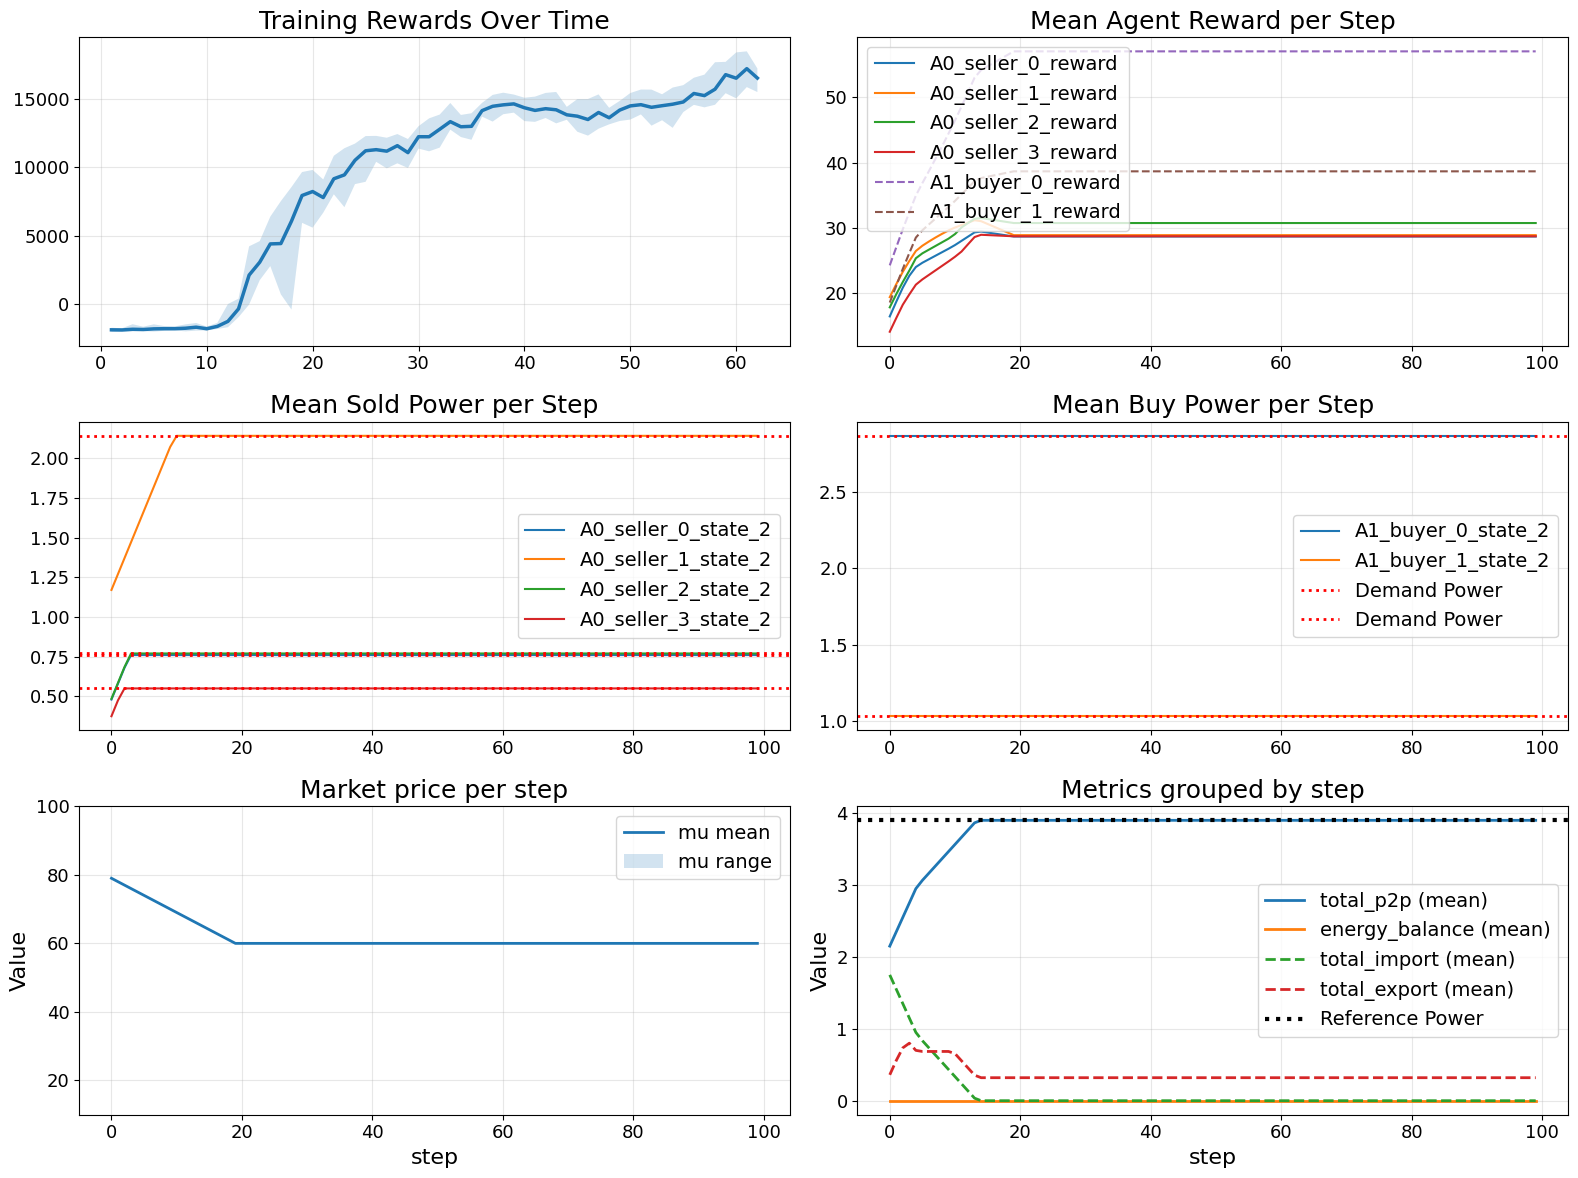

In [14]:
exp_name = "exp_results_2026-03-04_11-41-53"
training_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/progress.csv"
eval_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/evaluation_agent_states.csv"
mu_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/custom_metrics.csv"
# mu_path = f"./exp_results_2026-02-12_12-48-11/energy_market_training/PPO_energy_market_run/custom_metrics.csv"

full_analysis_plot(training_path, eval_path, mu_path, seller_power_reference=[0.76, 2.14, 0.77, 0.55, 2.87,1.03])

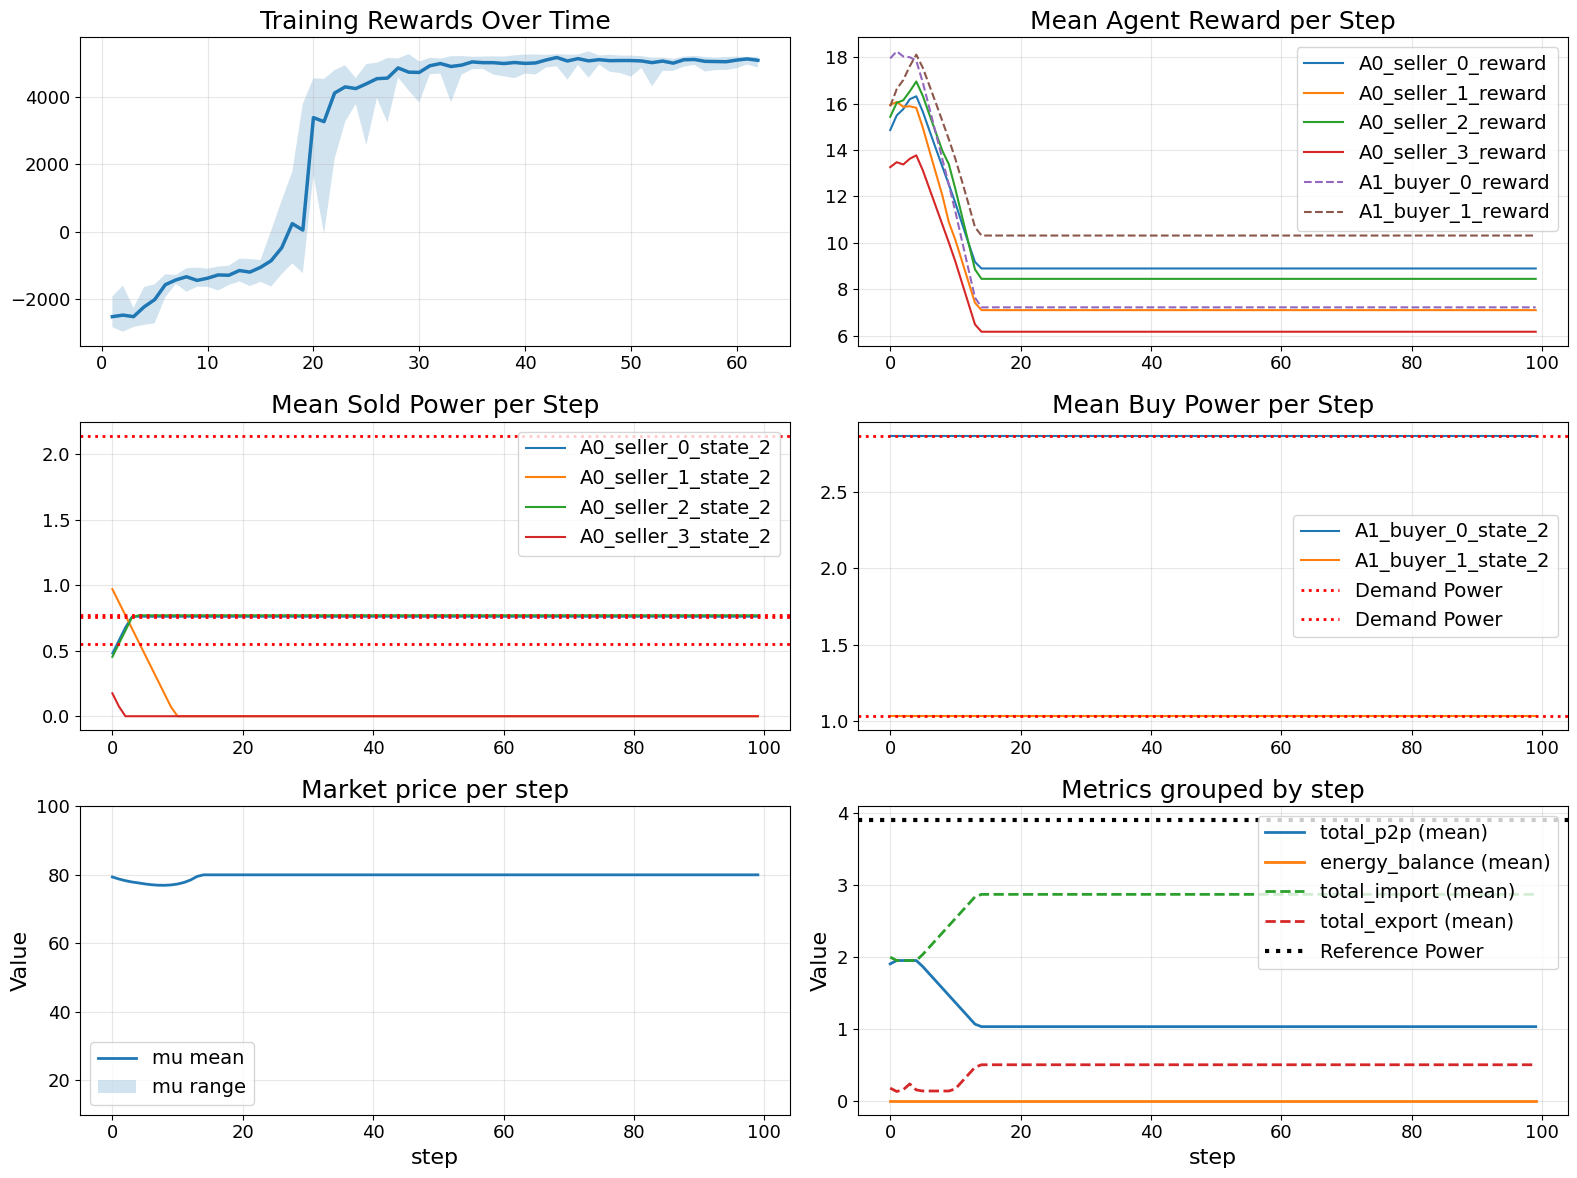

In [23]:
exp_name = "exp_results_2026-03-04_17-30-37"
training_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/progress.csv"
eval_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/evaluation_agent_states.csv"
mu_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/custom_metrics.csv"
# mu_path = f"./exp_results_2026-02-12_12-48-11/energy_market_training/PPO_energy_market_run/custom_metrics.csv"

full_analysis_plot(training_path, eval_path, mu_path, seller_power_reference=[0.76, 2.14, 0.77, 0.55, 2.87,1.03])

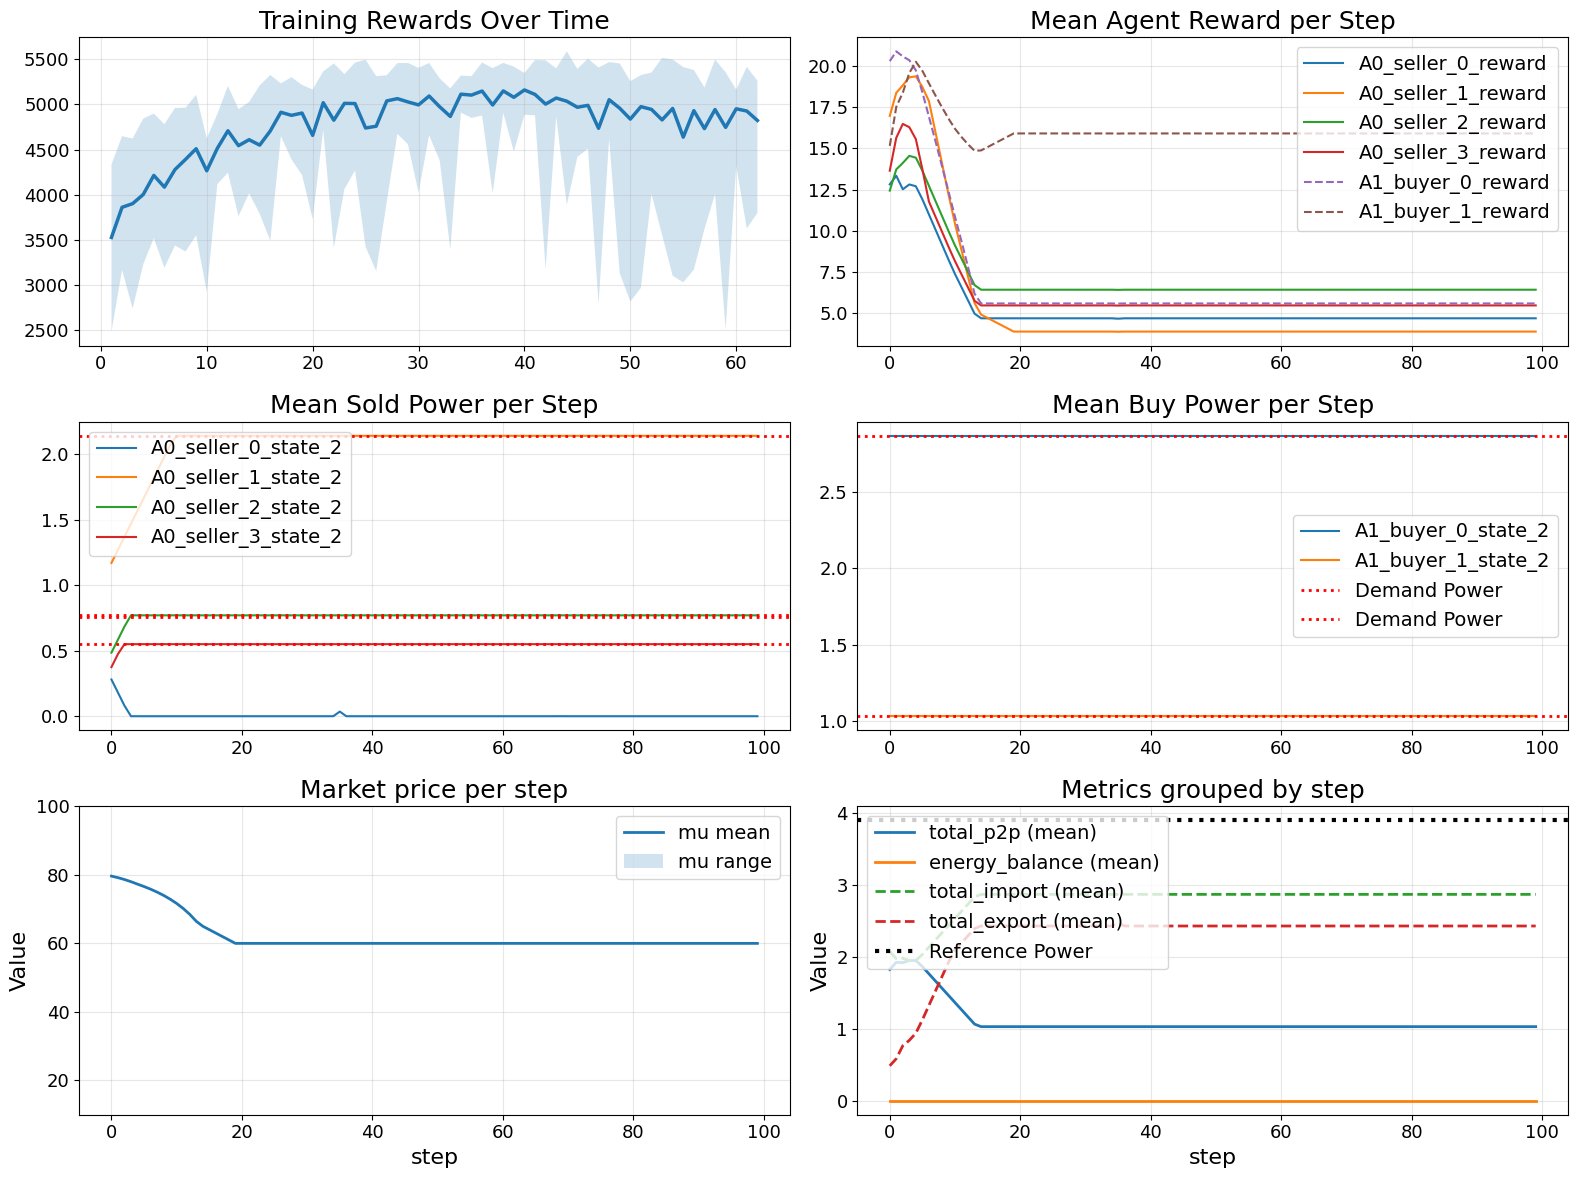

In [24]:
exp_name = "exp_results_2026-03-04_17-56-27"
training_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/progress.csv"
eval_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/evaluation_agent_states.csv"
mu_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/custom_metrics.csv"
# mu_path = f"./exp_results_2026-02-12_12-48-11/energy_market_training/PPO_energy_market_run/custom_metrics.csv"

full_analysis_plot(training_path, eval_path, mu_path, seller_power_reference=[0.76, 2.14, 0.77, 0.55, 2.87,1.03])

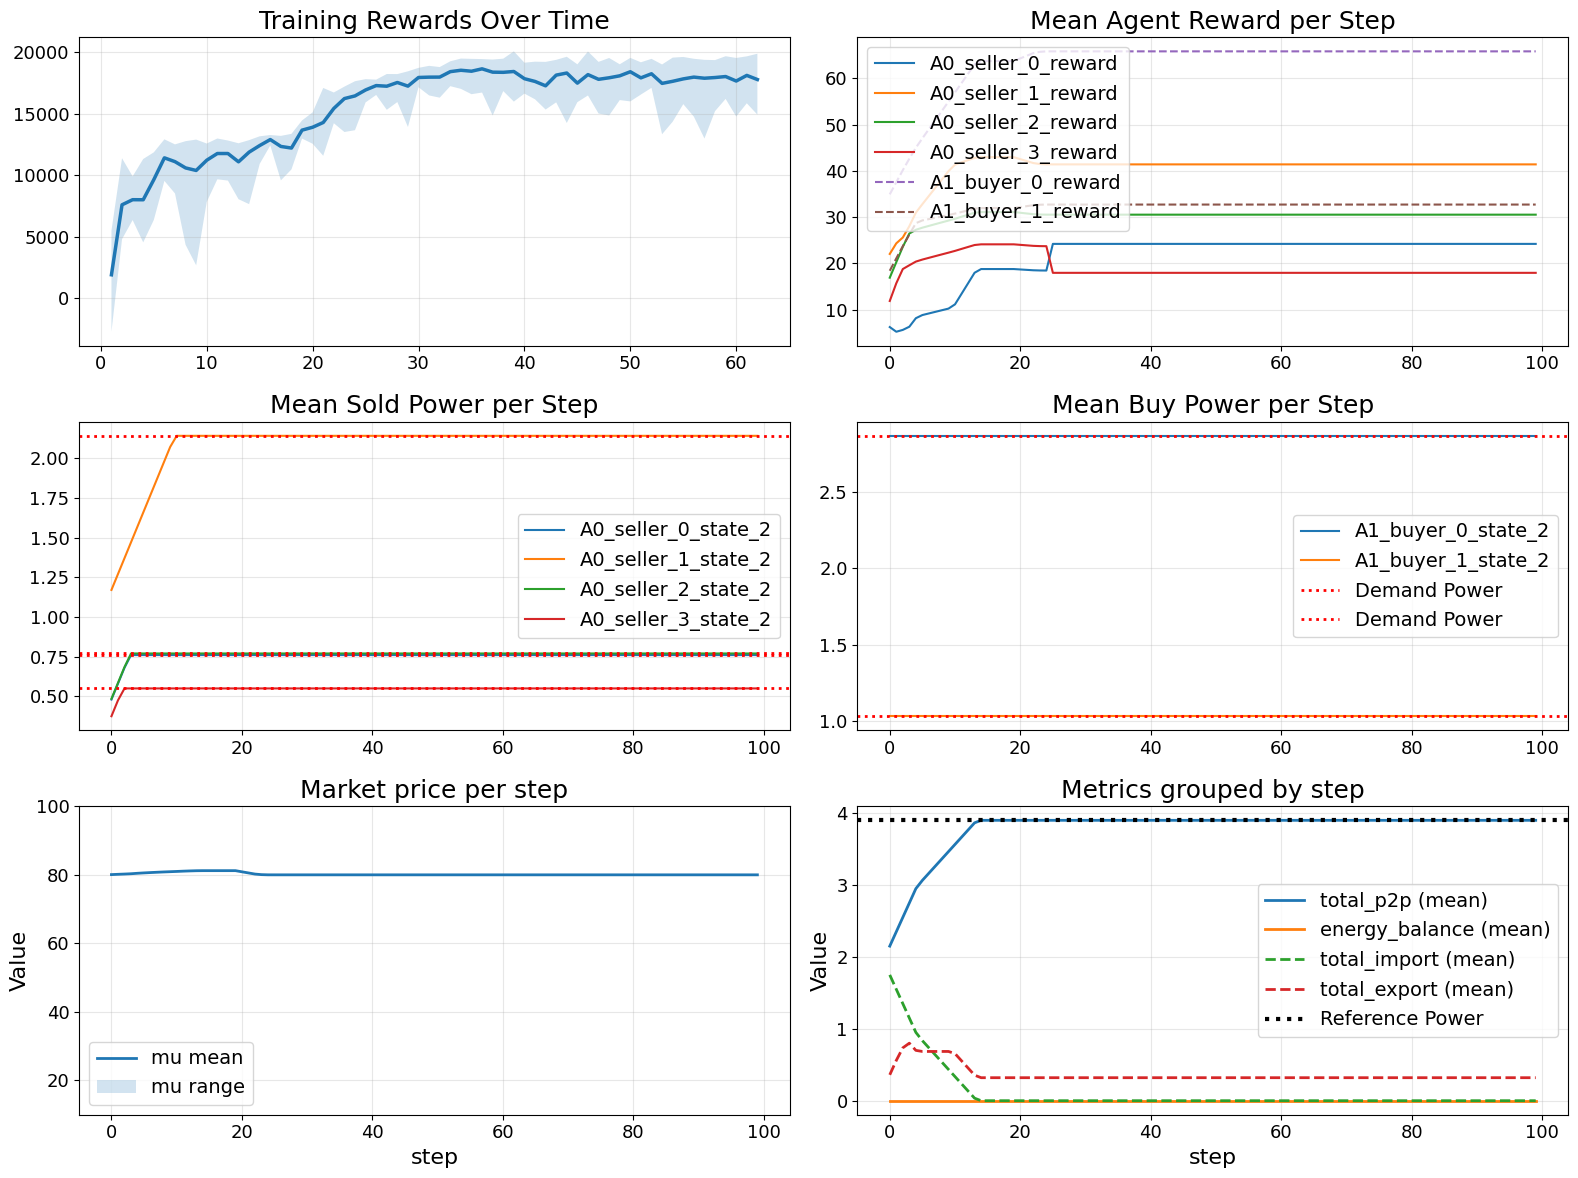

In [25]:
exp_name = "exp_results_2026-03-04_18-30-49"
training_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/progress.csv"
eval_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/evaluation_agent_states.csv"
mu_path = f"./{exp_name}/energy_market_training/PPO_energy_market_run/custom_metrics.csv"
# mu_path = f"./exp_results_2026-02-12_12-48-11/energy_market_training/PPO_energy_market_run/custom_metrics.csv"

full_analysis_plot(training_path, eval_path, mu_path, seller_power_reference=[0.76, 2.14, 0.77, 0.55, 2.87,1.03])